In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path
from typing import List, Tuple

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


## Dataset Configuration

In [35]:
# --- Directory paths ---
TRAIN_IMG_DIR = "../00_data/U-DIADS-TL/Latin2/img-Latin2/training/"
TRAIN_MASK_DIR = "../00_data/U-DIADS-TL/Latin2/text-line-gt-Latin2/training/"
VAL_IMG_DIR = "../00_data/U-DIADS-TL/Latin2/img-Latin2/validation/"
VAL_MASK_DIR = "../00_data/U-DIADS-TL/Latin2/text-line-gt-Latin2/validation/"
TEST_IMG_DIR = "../00_data/U-DIADS-TL/Latin2/img-Latin2/test/"
TEST_MASK_DIR = "../00_data/U-DIADS-TL/Latin2/text-line-gt-Latin2/test/"

# Crop parameters
CROP_SIZE = 512
STRIDE = 256

def get_file_paths(img_dir: str, mask_dir: str = None) -> Tuple[List[str], List[str]]:
    """Get sorted lists of image and mask file paths."""
    img_dir = Path(img_dir)
    mask_dir = Path(mask_dir) if mask_dir else None
    
    if not img_dir.exists():
        print(f"Warning: {img_dir} does not exist")
        return [], []
    
    images = sorted([str(f) for f in img_dir.glob('*.jpg')])
    
    if mask_dir:
        if not mask_dir.exists():
            print(f"Warning: {mask_dir} does not exist")
            return images, []
        masks = sorted([str(f) for f in mask_dir.glob('*.png')])
        return images, masks
    
    return images, []

# Load file paths
TRAIN_IMAGE_PATHS, TRAIN_MASK_PATHS = get_file_paths(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
VAL_IMAGE_PATHS, VAL_MASK_PATHS = get_file_paths(VAL_IMG_DIR, VAL_MASK_DIR)
TEST_IMAGE_PATHS, TEST_MASK_PATHS = get_file_paths(TEST_IMG_DIR, TEST_MASK_DIR)

print(f"Found {len(TRAIN_IMAGE_PATHS)} training images")
print(f"Found {len(VAL_IMAGE_PATHS)} validation images")
print(f"Found {len(TEST_IMAGE_PATHS)} test images")

Found 3 training images
Found 10 validation images
Found 15 test images


## Create Cuts from Connected Components (Text Lines)

In [36]:
def create_cuts_from_connected_components(image_paths: List[str], mask_paths: List[str], 
                                          padding: int = 10, output_dir: str = None) -> List[Tuple]:
    """
    Create cuts from images based on connected components (text lines) in masks.
    Each connected component (text line) becomes a separate cut.
    
    Args:
        image_paths: List of image file paths
        mask_paths: List of corresponding mask file paths
        padding: Padding around each connected component (default 10)
        output_dir: Optional directory to save cuts
    
    Returns:
        List of tuples (image_cut, mask_cut, original_image_name, component_idx)
    """
    cuts = []
    
    if output_dir:
        os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'masks'), exist_ok=True)
    
    for img_idx, (img_path, mask_path) in enumerate(zip(image_paths, mask_paths)):
        # Load image and mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None or mask is None:
            print(f"Warning: Could not load {img_path} or {mask_path}")
            continue
        
        h, w = img.shape[:2]
        
        # Threshold mask to binary
        _, mask_binary = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
        
        # Find connected components
        num_labels, labels = cv2.connectedComponents(mask_binary)
        
        img_name = os.path.basename(img_path)
        base_name = os.path.splitext(img_name)[0]
        
        # Iterate through each connected component (skip background, label 0)
        for component_id in range(1, num_labels):
            # Get bounding box of component
            component_mask = (labels == component_id).astype(np.uint8) * 255
            contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if not contours:
                continue
            
            # Get bounding rectangle
            x, y, bw, bh = cv2.boundingRect(contours[0])
            
            # Add padding
            x1 = max(0, x - padding)
            y1 = max(0, y - padding)
            x2 = min(w, x + bw + padding)
            y2 = min(h, y + bh + padding)
            
            # Extract cuts
            img_cut = img[y1:y2, x1:x2]
            mask_cut = mask[y1:y2, x1:x2]
            
            # Clean mask: keep only pixels belonging to current component
            # Extract the component mask for this region
            component_mask_region = (labels[y1:y2, x1:x2] == component_id).astype(np.uint8) * 255
            # Apply it to the mask cut to remove pixels from other components
            mask_cut = cv2.bitwise_and(mask_cut, component_mask_region)
            
            # Only keep cuts with minimum size
            if img_cut.shape[0] > 10 and img_cut.shape[1] > 10:
                cuts.append((img_cut, mask_cut, base_name, component_id))
                
                # Save if output directory provided
                if output_dir:
                    img_save_path = os.path.join(output_dir, 'images', f"{base_name}_line{component_id:04d}.jpg")
                    mask_save_path = os.path.join(output_dir, 'masks', f"{base_name}_line{component_id:04d}.png")
                    
                    cv2.imwrite(img_save_path, img_cut)
                    cv2.imwrite(mask_save_path, mask_cut)
    
    print(f"Created {len(cuts)} cuts from {len(image_paths)} images (one cut per text line)")
    return cuts

print("create_cuts_from_connected_components function defined")

create_cuts_from_connected_components function defined


## Create Cuts

In [37]:
# Create cuts from training dataset (one cut per connected component/text line)
train_cuts = create_cuts_from_connected_components(
    TRAIN_IMAGE_PATHS, 
    TRAIN_MASK_PATHS, 
    padding=10,
    output_dir=None  # Set to a directory path to save cuts
)

# Create cuts from validation dataset
val_cuts = create_cuts_from_connected_components(
    VAL_IMAGE_PATHS,
    VAL_MASK_PATHS,
    padding=10,
    output_dir=None
)

# Create cuts from test dataset
test_cuts = create_cuts_from_connected_components(
    TEST_IMAGE_PATHS,
    TEST_MASK_PATHS,
    padding=10,
    output_dir=None
)

print(f"\nTotal cuts created:")
print(f"  Training: {len(train_cuts)}")
print(f"  Validation: {len(val_cuts)}")
print(f"  Test: {len(test_cuts)}")

Created 318 cuts from 3 images (one cut per text line)
Created 958 cuts from 10 images (one cut per text line)
Created 1470 cuts from 15 images (one cut per text line)

Total cuts created:
  Training: 318
  Validation: 958
  Test: 1470


## Visualization Functions

In [38]:
def plot_cut_with_groundtruth(img_cut, mask_cut, title="Image Cut with Ground Truth", figsize=(14, 6)):
    """
    Plot a single image cut alongside its ground truth mask.
    
    Args:
        img_cut: Image cut (numpy array in BGR format from cv2)
        mask_cut: Mask cut (numpy array in grayscale)
        title: Title for the figure
        figsize: Figure size (width, height)
    """
    # Convert BGR to RGB for display
    img_rgb = cv2.cvtColor(img_cut, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Plot original image
    axes[0].imshow(img_rgb)
    axes[0].set_title('Image Cut')
    axes[0].axis('off')
    
    # Plot ground truth mask
    axes[1].imshow(mask_cut, cmap='gray')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # Plot overlay (image with mask overlay)
    overlay = img_rgb.copy()
    mask_colored = cv2.applyColorMap((mask_cut > 128).astype(np.uint8) * 255, cv2.COLORMAP_JET)
    mask_colored_rgb = cv2.cvtColor(mask_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(overlay, 0.7, mask_colored_rgb, 0.3, 0)
    
    axes[2].imshow(overlay)
    axes[2].set_title('Image + Mask Overlay')
    axes[2].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("plot_cut_with_groundtruth function defined")

plot_cut_with_groundtruth function defined


## Visualize Random Cuts

Displaying cut 58 from image: 019
Image shape: (48, 390, 3), Mask shape: (48, 390)
Mask unique values: [  0 255]
Text coverage: 1.46%


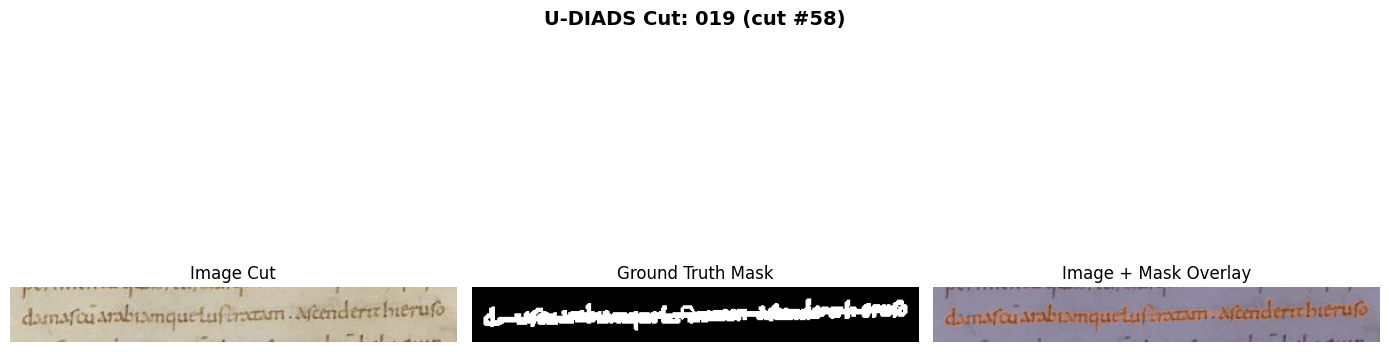

In [39]:
# Select a random cut from training set and plot it
if train_cuts:
    random_idx = random.randint(0, len(train_cuts) - 1)
    img_cut, mask_cut, img_name, crop_idx = train_cuts[random_idx]
    
    print(f"Displaying cut {crop_idx} from image: {img_name}")
    print(f"Image shape: {img_cut.shape}, Mask shape: {mask_cut.shape}")
    print(f"Mask unique values: {np.unique(mask_cut)}")
    
    mask_binary = (mask_cut > 128).astype(np.uint8)
    text_coverage = (mask_binary.sum() / (CROP_SIZE * CROP_SIZE)) * 100
    print(f"Text coverage: {text_coverage:.2f}%")
    
    plot_cut_with_groundtruth(
        img_cut, 
        mask_cut, 
        title=f"U-DIADS Cut: {img_name} (cut #{crop_idx})"
    )

## Visualize Multiple Random Cuts

Displaying 3 random cuts from training dataset:

Sample 1: 019 (cut #13) - Text coverage: 1.55%


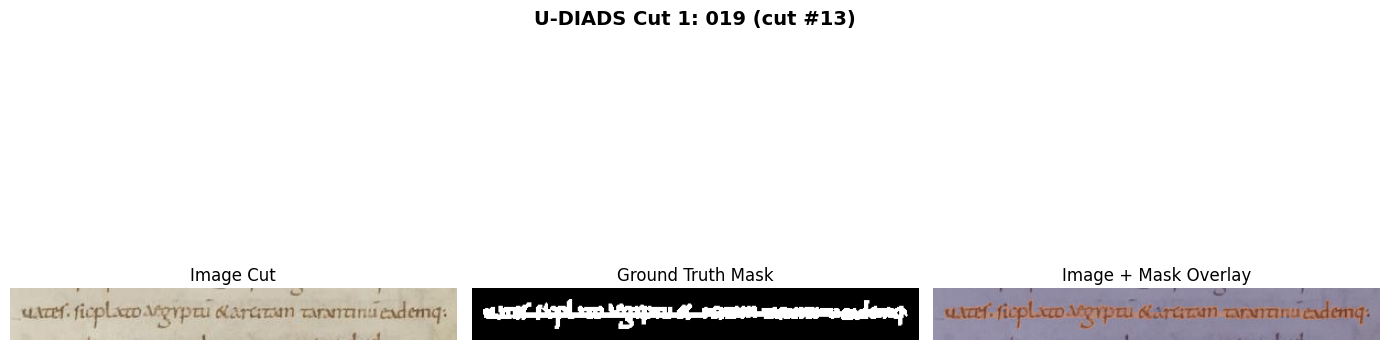

Sample 2: 065 (cut #76) - Text coverage: 1.66%


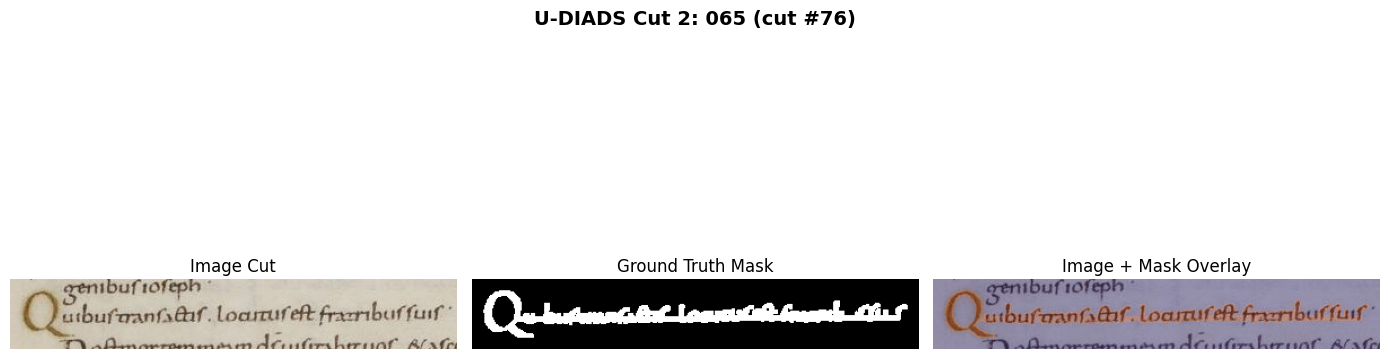

Sample 3: 065 (cut #61) - Text coverage: 1.57%


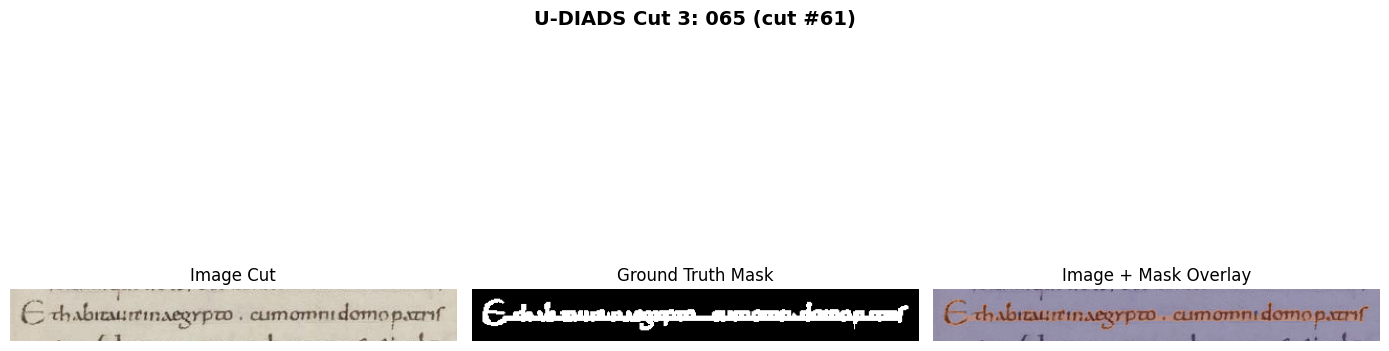

In [40]:
# Plot multiple random cuts
num_samples = 3
print(f"Displaying {num_samples} random cuts from training dataset:\n")

for i in range(min(num_samples, len(train_cuts))):
    random_idx = random.randint(0, len(train_cuts) - 1)
    img_cut, mask_cut, img_name, crop_idx = train_cuts[random_idx]
    
    mask_binary = (mask_cut > 128).astype(np.uint8)
    text_coverage = (mask_binary.sum() / (CROP_SIZE * CROP_SIZE)) * 100
    
    print(f"Sample {i+1}: {img_name} (cut #{crop_idx}) - Text coverage: {text_coverage:.2f}%")
    
    plot_cut_with_groundtruth(
        img_cut, 
        mask_cut, 
        title=f"U-DIADS Cut {i+1}: {img_name} (cut #{crop_idx})"
    )

# Segmentation Model - U-Net

Build and train a U-Net segmentation model using segmentation_models_pytorch.


In [41]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Install segmentation_models_pytorch if needed
# !pip install segmentation-models-pytorch
print("Ready to build U-Net model")

Using device: cuda
Ready to build U-Net model


In [42]:
class SegmentationDataset(Dataset):
    """Custom PyTorch dataset for segmentation cuts without resizing."""
    
    def __init__(self, cuts_list, transforms=None):
        """Args:
            cuts_list: List of tuples (img_cut, mask_cut, img_name, component_id)
            transforms: Optional augmentation transforms
        """
        self.cuts_list = cuts_list
        self.transforms = transforms
    
    def __len__(self):
        return len(self.cuts_list)
    
    def __getitem__(self, idx):
        img_cut, mask_cut, img_name, component_id = self.cuts_list[idx]

        # Ensure cuts are not too small for ResNet encoder (downsampling factor ~32).
        # To avoid 1x1 feature maps (which break BatchNorm with batch_size=1),
        # we upsample only very small cuts to at least 64x64.
        h, w = img_cut.shape[:2]
        MIN_SIZE = 64
        if h < MIN_SIZE or w < MIN_SIZE:
            new_h = max(MIN_SIZE, h)
            new_w = max(MIN_SIZE, w)
            img_cut = cv2.resize(img_cut, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
            mask_cut = cv2.resize(mask_cut, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
        # Convert BGR to RGB and normalize
        img_rgb = cv2.cvtColor(img_cut, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(img_rgb).float() / 255.0
        img_tensor = img_tensor.permute(2, 0, 1)  # HWC -> CHW
        
        # Convert mask to tensor
        mask_tensor = torch.from_numpy(mask_cut).float() / 255.0
        mask_tensor = mask_tensor.unsqueeze(0)  # Add channel dimension
        
        return img_tensor, mask_tensor

# Create datasets with original cut sizes
train_dataset = SegmentationDataset(train_cuts)
val_dataset = SegmentationDataset(val_cuts)
test_dataset = SegmentationDataset(test_cuts)

print(f"Training dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Training dataset size: 1470
Validation dataset size: 958
Test dataset size: 1470


In [43]:
# Create data loaders
# Note: we use batch_size=1 because cuts have varying spatial sizes,
# so they cannot be stacked into larger batches without padding.
BATCH_SIZE = 1

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 318
Val batches: 958
Test batches: 1470


In [44]:
import torch
import numpy as np
import cv2
import segmentation_models_pytorch as smp

# =========================
# Model
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_dropout=0.1
).to(DEVICE)

print("Model created and moved to device:", DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# =========================
# Loss
# =========================

bce_loss_fn = torch.nn.BCEWithLogitsLoss()

# =========================
# Optimizer & Scheduler
# =========================

optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

# =========================
# Otsu (validation only)
# =========================

def otsu_batch(probs: torch.Tensor) -> torch.Tensor:
    probs_np = probs.detach().cpu().numpy()[:, 0]  # (B, H, W)
    bin_masks = np.zeros_like(probs_np, dtype=np.uint8)

    for i in range(probs_np.shape[0]):
        p = (probs_np[i] * 255).astype(np.uint8)
        _, bin_masks[i] = cv2.threshold(
            p, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    bin_masks = torch.from_numpy(bin_masks).unsqueeze(1)
    return bin_masks.to(probs.device).float() / 255.0

# =========================
# Training
# =========================

NUM_EPOCHS = 10
best_val_dice = 0.0

train_losses = []
val_dices = []

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):

    # -------- Training --------
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE).float()

        logits = model(imgs)
        loss = bce_loss_fn(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # -------- Validation (Dice) --------
    model.eval()
    val_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE).float()

            logits = model(imgs)
            probs = torch.sigmoid(logits)

            bin_masks = otsu_batch(probs)

            inter = (bin_masks * masks).sum(dim=(2, 3))
            union = bin_masks.sum(dim=(2, 3)) + masks.sum(dim=(2, 3))
            dice = (2 * inter + 1e-6) / (union + 1e-6)

            val_dice += dice.mean().item()

    val_dice /= len(val_loader)
    val_dices.append(val_dice)

    scheduler.step(val_dice)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_dice={val_dice:.4f}"
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(
            model.state_dict(),
            "../80_models/best_unet_u_diads_256x64.pth"
        )
        print(f"  ✓ Saved best model (val_dice={val_dice:.4f})")

print("\nTraining completed!")

Model created and moved to device: cuda
Model parameters: 24,436,369
Trainable parameters: 24,436,369
Starting training for 10 epochs...

Epoch 01 | train_loss=0.1290 | val_dice=0.9011
  ✓ Saved best model (val_dice=0.9011)
Epoch 02 | train_loss=0.0894 | val_dice=0.9018
  ✓ Saved best model (val_dice=0.9018)
Epoch 03 | train_loss=0.0841 | val_dice=0.9092
  ✓ Saved best model (val_dice=0.9092)
Epoch 04 | train_loss=0.0807 | val_dice=0.9034
Epoch 05 | train_loss=0.0780 | val_dice=0.9140
  ✓ Saved best model (val_dice=0.9140)
Epoch 06 | train_loss=0.0798 | val_dice=0.9130
Epoch 07 | train_loss=0.0749 | val_dice=0.9154
  ✓ Saved best model (val_dice=0.9154)
Epoch 08 | train_loss=0.0717 | val_dice=0.9133
Epoch 09 | train_loss=0.0706 | val_dice=0.9157
  ✓ Saved best model (val_dice=0.9157)
Epoch 10 | train_loss=0.0687 | val_dice=0.9192
  ✓ Saved best model (val_dice=0.9192)

Training completed!


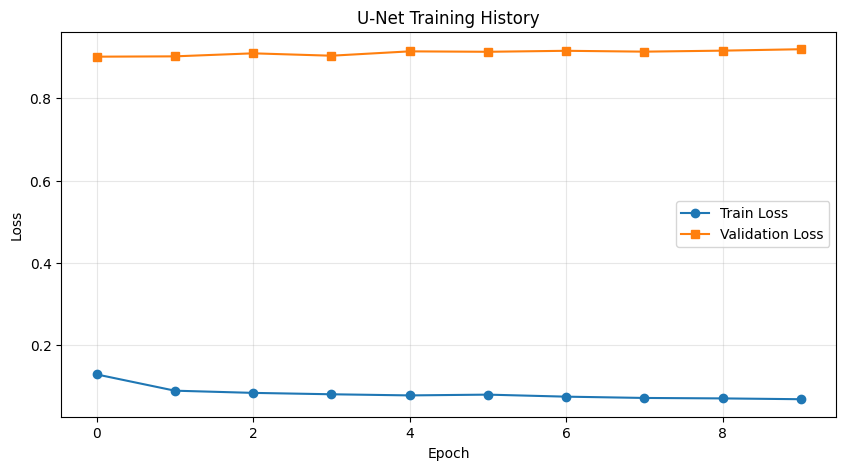

In [45]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_dices, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('U-Net Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [46]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_dropout=0.1
).to(DEVICE)


model.load_state_dict(torch.load("../80_models/best_unet_u_diads_256x64.pth"))
model.eval()
print("Best model loaded for evaluation on test set")

Best model loaded for evaluation on test set


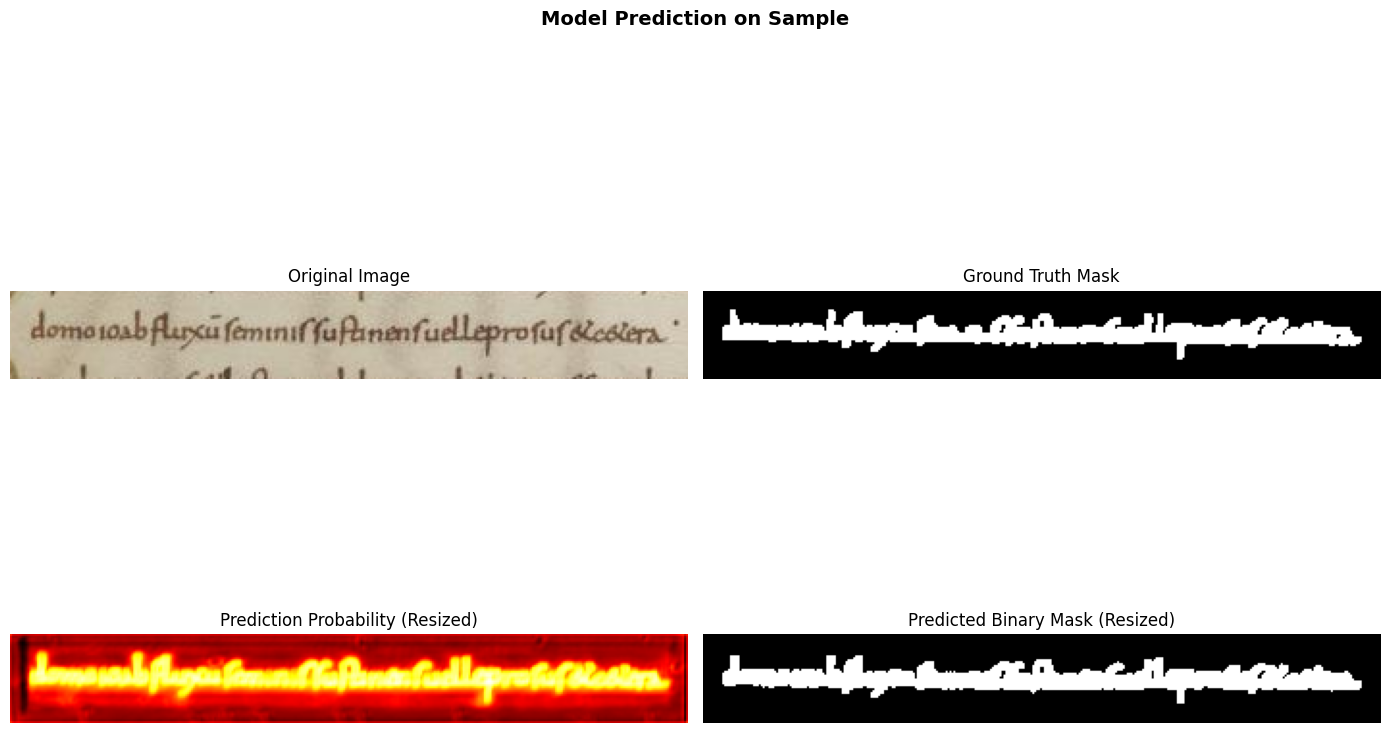

In [60]:
def predict_segmentation(model, img_tensor, device, threshold=0.5):
    """Predict segmentation for a single image."""
    model.eval()
    
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension
    
    img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        prediction = model(img_tensor)
    
    # Convert to numpy
    pred_mask = prediction.squeeze().cpu().numpy()
    pred_binary = (pred_mask > threshold).astype(np.uint8) * 255
    
    return pred_mask, pred_binary

def visualize_prediction(img_cut, mask_cut, pred_mask, pred_binary, title="Segmentation Prediction"):
    """Visualize original, ground truth, and predictions resized to original size."""
    img_rgb = cv2.cvtColor(img_cut, cv2.COLOR_BGR2RGB)
    
    # Get original dimensions
    orig_h, orig_w = img_rgb.shape[:2]
    
    # Resize predictions to original size
    pred_mask_resized = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    pred_binary_resized = cv2.resize(pred_binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Original image
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Ground truth mask
    axes[0, 1].imshow(mask_cut, cmap='gray')
    axes[0, 1].set_title('Ground Truth Mask')
    axes[0, 1].axis('off')
    
    # Predicted probability (resized)
    axes[1, 0].imshow(pred_mask_resized, cmap='hot')
    axes[1, 0].set_title('Prediction Probability (Resized)')
    axes[1, 0].axis('off')
    
    # Predicted binary mask (resized)
    axes[1, 1].imshow(pred_binary_resized, cmap='gray')
    axes[1, 1].set_title('Predicted Binary Mask (Resized)')
    axes[1, 1].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test on a sample
if test_dataset:
    # random
    random_idx = random.randint(0, len(test_dataset) - 1)
    sample_img, sample_mask = test_dataset[random_idx]
    pred_mask, pred_binary = predict_segmentation(model, sample_img, DEVICE)
    
    img_cut = test_cuts[random_idx][0]
    mask_cut = test_cuts[random_idx][1]
    visualize_prediction(img_cut, mask_cut, pred_mask, pred_binary, "Model Prediction on Sample")


Mean IoU on test set: 0.8606
Min IoU: 0.1282, Max IoU: 0.9364


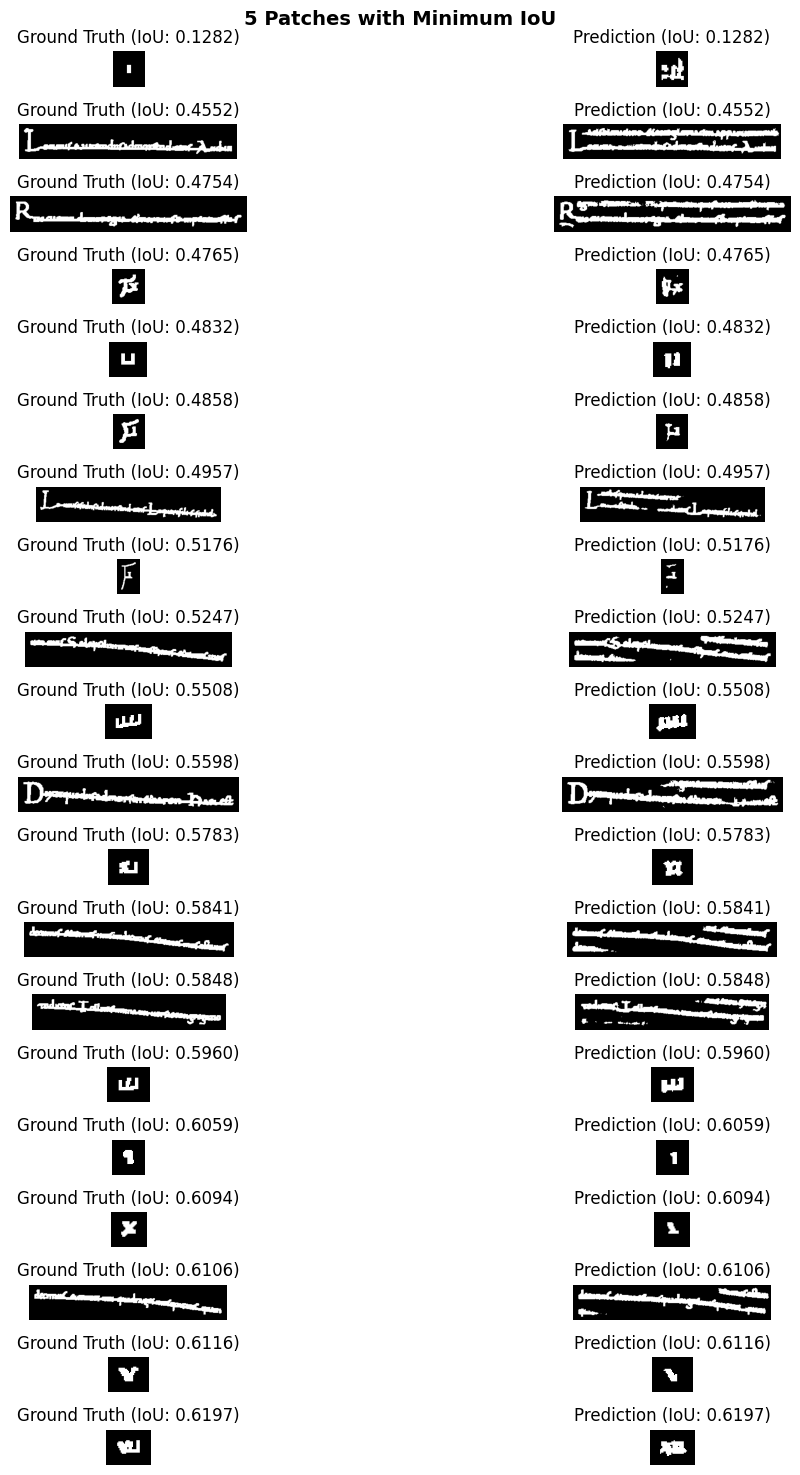

In [62]:
# calulate mean iou for all test patches

ious = []
model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        bin_masks = otsu_batch(probs)
        
        # Calculate IoU for each sample in batch
        inter = (bin_masks * masks).sum(dim=(2, 3))
        union = bin_masks.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) - inter
        iou = (inter + 1e-6) / (union + 1e-6)
        ious.extend(iou.cpu().numpy().flatten().tolist())

mean_iou = np.mean(ious)
print(f"Mean IoU on test set: {mean_iou:.4f}")
print(f"Min IoU: {np.min(ious):.4f}, Max IoU: {np.max(ious):.4f}")

# Find 5 patches with minimum IoU
min_iou_indices = np.argsort(ious)[:20]

fig, axes = plt.subplots(20, 2, figsize=(12, 15))
for i, idx in enumerate(min_iou_indices):
    img_cut = test_cuts[idx][0]
    mask_cut = test_cuts[idx][1]
    
    # Get prediction
    sample_img, sample_mask = test_dataset[idx]
    pred_mask, pred_binary = predict_segmentation(model, sample_img, DEVICE)
    
    # Resize predictions to original size
    orig_h, orig_w = img_cut.shape[:2]
    pred_binary_resized = cv2.resize(pred_binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_cut, cv2.COLOR_BGR2RGB)
    
    # Ground truth
    axes[i, 0].imshow(mask_cut, cmap='gray')
    axes[i, 0].set_title(f'Ground Truth (IoU: {ious[idx]:.4f})')
    axes[i, 0].axis('off')
    
    # Prediction
    axes[i, 1].imshow(pred_binary_resized, cmap='gray')
    axes[i, 1].set_title(f'Prediction (IoU: {ious[idx]:.4f})')
    axes[i, 1].axis('off')

plt.suptitle('5 Patches with Minimum IoU', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
